# Cell 1 - Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


c:\Users\srkap\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Cell 2 — Load & Merge All Sheets

In [2]:
xl = pd.ExcelFile('timetable_training.xlsx')
df = pd.concat(
    [xl.parse(sheet).assign(Sheet=sheet) for sheet in xl.sheet_names],
    ignore_index=True
)
print(f'Total rows loaded: {len(df)}')
df.head()


Total rows loaded: 547


,Sheet,Class,Semester,Division,Day,Slot No,Slot Time,Batch,Subject,Faculty,Room,Session Type,Color Legend
0,Timetable Dataset,B Tech,VI,A,TUE,4.0,10:30-11:25,All,MAKEUP / PROBLEM SOLVING SESSION,NaN,NaN,Theory,NaN
1,Timetable Dataset,B Tech,VI,A,TUE,7.0,13:15-14:10,All,GAA3,PEC Lab,SM-RL (H305),Lab,NaN
2,Timetable Dataset,B Tech,VI,A,TUE,7.0,13:15-14:10,All,GAA3,PEC Lab,SM-RL (H305),Lab,NaN
3,Timetable Dataset,B Tech,VI,A,TUE,10.0,15:10-16:00,All,BDA(PEC)-PAD-H301,GAA(PEC) SSM-H302,EHCL(PEC)-PM-H303,Theory,NaN
4,Timetable Dataset,B Tech,VI,A,TUE,10.0,15:10-16:00,All,BDA(PEC)-PAD-H301,GAA(PEC) SSM-H302,EHCL(PEC)-PM-H303,Theory,NaN


# Cell 3 — Clean & Preprocess

In [3]:
df.dropna(subset=['Faculty', 'Subject', 'Room', 'Day', 'Slot No', 'Session Type'], inplace=True)
str_cols = ['Faculty', 'Subject', 'Room', 'Day', 'Batch', 'Division', 'Class', 'Session Type', 'Semester']
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()
print(df.dtypes)
print(df.shape)


Sheet            object
Class            object
Semester         object
Division         object
Day              object
Slot No         float64
Slot Time        object
Batch            object
Subject          object
Faculty          object
Room             object
Session Type     object
Color Legend     object
dtype: object
(461, 13)


# Cell 4 — Label Encoding

In [4]:
encode_cols = ['Faculty', 'Subject', 'Room', 'Day', 'Division', 'Class', 'Batch', 'Session Type', 'Semester']
encoders = {}
for col in encode_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le
os.makedirs('../backend/app/ml', exist_ok=True)
with open('../backend/app/ml/label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print('Label encoders saved → backend/app/ml/label_encoders.pkl')


Label encoders saved → backend/app/ml/label_encoders.pkl


# Cell 5 — Normalize & Build Sequences

In [5]:
feature_cols = ['Slot No', 'Faculty_enc', 'Subject_enc', 'Room_enc', 'Day_enc', 'Division_enc', 'Class_enc', 'Batch_enc', 'Session Type_enc', 'Semester_enc']
target_col = 'Subject_enc'
SEQ_LEN = 10
X_raw = df[feature_cols].values.astype(float)
y_raw = df[target_col].values
X_raw = (X_raw - X_raw.min(axis=0)) / (X_raw.max(axis=0) - X_raw.min(axis=0) + 1e-8)
X, y = [], []
for i in range(len(X_raw) - SEQ_LEN):
    X.append(X_raw[i:i + SEQ_LEN])
    y.append(y_raw[i + SEQ_LEN])
X = np.array(X)
n_classes = len(encoders['Subject'].classes_)
y = to_categorical(y, num_classes=n_classes)
print(f'X shape: {X.shape}  |  y shape: {y.shape}  |  Classes: {n_classes}')


X shape: (451, 10, 10)  |  y shape: (451, 55)  |  Classes: 55


# Cell 6 — Train/Validation Split

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')


Train: (360, 10, 10)  |  Val: (91, 10, 10)


# Cell 7 — Build LSTM Model

In [7]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, len(feature_cols))),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\srkap\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 55)             │         1,815 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,471 (486.21 KB)

 Trainable params: 124,471 (486.21 KB)

 Non-trainable params: 0 (0.00 B)

# Cell 8 — Train

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.0222 - loss: 3.9335 - val_accuracy: 0.0330 - val_loss: 3.8473
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0556 - loss: 3.7004 - val_accuracy: 0.0769 - val_loss: 3.7524
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1000 - loss: 3.5400 - val_accuracy: 0.0769 - val_loss: 3.6887
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1250 - loss: 3.4248 - val_accuracy: 0.0879 - val_loss: 3.6176
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1250 - loss: 3.3379 - val_accuracy: 0.1099 - val_loss: 3.5378
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1278 - loss: 3.2532 - val_accuracy: 0.1319 - val_loss: 3.4665
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1722 - loss: 3.1763 - val_accuracy: 0.1538 - val_loss: 3.4211
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2056 - loss: 3.1023 - val_accuracy: 0.1538 - v

# Cell 9 — Save Model & Training History

In [9]:
model.save('../backend/app/ml/lstm_model.h5')
print('Model saved → backend/app/ml/lstm_model.h5')
history_data = {
    'epochs':       list(range(1, len(history.history['loss']) + 1)),
    'loss':         [float(v) for v in history.history['loss']],
    'val_loss':     [float(v) for v in history.history['val_loss']],
    'accuracy':     [float(v) for v in history.history['accuracy']],
    'val_accuracy': [float(v) for v in history.history['val_accuracy']]
}
with open('../backend/app/ml/training_history.json', 'w') as f:
    json.dump(history_data, f, indent=2)
print('Training history saved → backend/app/ml/training_history.json')


Model saved → backend/app/ml/lstm_model.h5
Training history saved → backend/app/ml/training_history.json


# Cell 10 — Plot & Verify

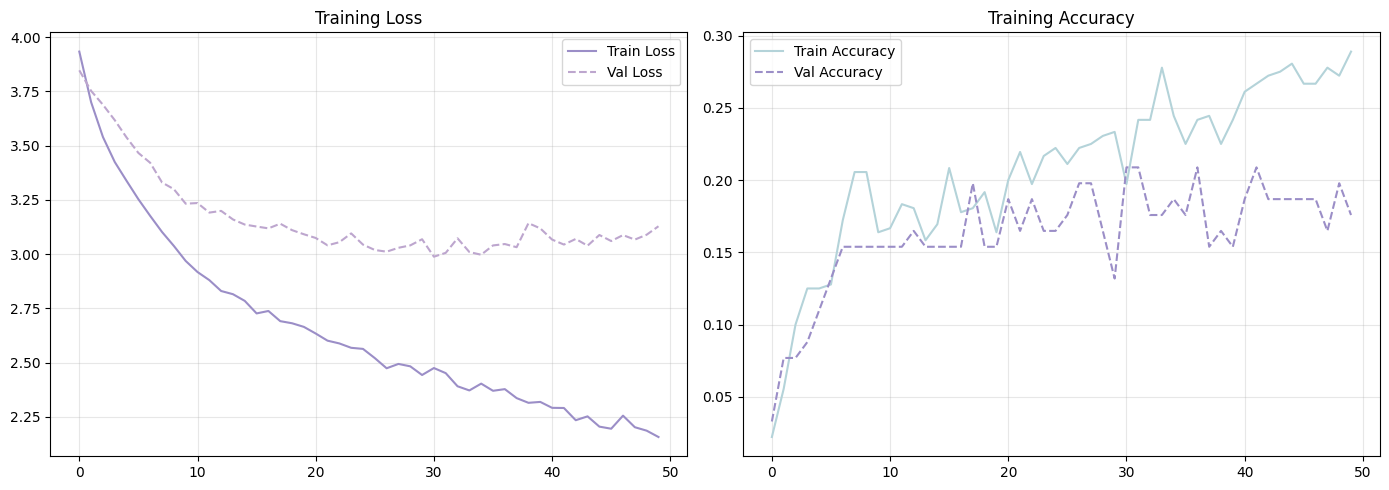

Plot saved → backend/app/ml/training_plot.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_data['loss'],     label='Train Loss',      color='#9B8EC7')
ax1.plot(history_data['val_loss'], label='Val Loss',        color='#BDA6CE', linestyle='--')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history_data['accuracy'],     label='Train Accuracy', color='#B4D3D9')
ax2.plot(history_data['val_accuracy'], label='Val Accuracy',   color='#9B8EC7', linestyle='--')
ax2.set_title('Training Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../backend/app/ml/training_plot.png', dpi=150)
plt.show()
print('Plot saved → backend/app/ml/training_plot.png')
